# Geospatial Machine Learning — Random Forest Classification with Spatial Cross-Validation

This notebook adapts the previous spatial Random Forest workflow from **regression** to **binary classification** of *Araucaria angustifolia* occurrence.

The response variable is:

- `0` = pseudo-absence
- `1` = presence

**Spatial validation strategy**

- fixed 2° × 2° geographic blocks;
- complete blocks assigned to either training or independent testing;
- approximately **80% of samples for training** and **20% for independent spatial testing**;
- training blocks assigned to **10 spatial cross-validation folds**;
- no block is shared between training and validation/test partitions.

**Outputs**

1. `Araucaria_RF_binary_spatialcv.tif` — binary prediction (`0` / `1`)
2. `Araucaria_RF_probability_spatialcv.tif` — probability of Araucaria presence (`0–1`)

A probability threshold of **0.50** is used to create the binary map.


In [1]:
# Import libraries.
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

from shapely.geometry import box

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)
from sklearn.inspection import permutation_importance


## 1. Define paths and load the sample data

The sample GeoPackage contains both presences and pseudo-absences in the same layer. The column `presence` is the binary response.


In [2]:
# Define input and output paths.
samples_path = Path(
    "/home/jovyan/grupos/pgrad-disciplinas/"
    "CAP-423-ciencia-de-dados-geoespaciais/dataset/input/"
    "Araucaria_pseudo_absence.gpkg"
)

# Predictor rasters are expected in the same input folder.
# Change this path only if your GeoTIFF predictors are stored elsewhere.
PREDICTOR_DIR = samples_path.parent
OUTPUT_DIR = samples_path.parent.parent / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Read presence/pseudo-absence samples.
samples = gpd.read_file(samples_path)

if "presence" not in samples.columns:
    raise ValueError("The sample file must contain a 'presence' column.")

# Ensure a binary integer response.
samples["presence"] = samples["presence"].astype(int)

if not set(samples["presence"].unique()).issubset({0, 1}):
    raise ValueError("The 'presence' column must contain only 0 and 1.")

print("Samples:", len(samples))
print()
print("Class distribution:")
print(samples["presence"].value_counts().sort_index())

display(samples.head())


Samples: 6906

Class distribution:
presence
0    3453
1    3453
Name: count, dtype: int64


,id,presence,geometry
0,1,1,POINT (-49.61149 -28.06746)
1,2,1,POINT (-49.96145 -28.28208)
2,3,1,POINT (-52.27105 -29.39495)
3,4,1,POINT (-48.97911 -25.38728)
4,5,1,POINT (-53.03313 -24.19717)


## 2. Load the raster predictors

Every GeoTIFF in `PREDICTOR_DIR` is used as a predictor. The file stem becomes the predictor name.


In [3]:
# List GeoTIFF predictors.
raster_files = sorted(PREDICTOR_DIR.glob("*.tif"))

if not raster_files:
    raise FileNotFoundError(
        f"No GeoTIFF predictors were found in: {PREDICTOR_DIR}"
    )

raster_names = [f.stem for f in raster_files]

print(f"Number of raster predictors: {len(raster_files)}")
for f in raster_files:
    print(f.name)


Number of raster predictors: 25
HAND.tif
Mean_curvature.tif
NTSI.tif
TPI_11x11.tif
bio1.tif
bio10.tif
bio11.tif
bio12.tif
bio13.tif
bio14.tif
bio15.tif
bio16.tif
bio17.tif
bio18.tif
bio19.tif
bio2.tif
bio3.tif
bio4.tif
bio5.tif
bio6.tif
bio7.tif
bio8.tif
bio9.tif
elevation.tif
slope.tif


## 3. Extract raster values at sample locations

Samples are transformed to the raster CRS before extraction. Spatial blocks are defined in geographic coordinates, so the predictor grid must use a geographic CRS for this workflow.


In [4]:
# Check sample and raster CRS.
with rasterio.open(raster_files[0]) as src:
    raster_crs = src.crs

print("Sample CRS:", samples.crs)
print("Raster CRS:", raster_crs)

if samples.crs != raster_crs:
    samples = samples.to_crs(raster_crs)

if not samples.crs.is_geographic:
    raise ValueError(
        "The sample/raster CRS must be geographic to create 2° x 2° blocks."
    )


Sample CRS: EPSG:4326
Raster CRS: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]


ERROR 1: PROJ: internal_proj_identify: /opt/conda/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 3 whereas a number >= 6 is expected. It comes from another PROJ installation.


In [5]:
# Extract predictor values at sample locations.
coords = [(geom.x, geom.y) for geom in samples.geometry]

for raster_path, raster_name in zip(raster_files, raster_names):
    with rasterio.open(raster_path) as src:
        values = np.array([v[0] for v in src.sample(coords)], dtype="float64")

        if src.nodata is not None:
            values[values == src.nodata] = np.nan

        samples[raster_name] = values

display(samples.head())


,id,presence,geometry,HAND,Mean_curvature,NTSI,TPI_11x11,bio1,bio10,bio11,...,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,elevation,slope
0,1,1,POINT (-49.61149 -28.06746),543.000000,-0.000022,-0.001883,49.223141,12.920834,16.483334,9.466666,...,9.225000,53.633720,288.463470,21.500000,4.3,17.200001,16.483334,11.200000,1433.0,4.962794
1,2,1,POINT (-49.96145 -28.28208),368.000000,-0.000008,-0.002379,20.628099,13.850000,17.433334,10.333333,...,9.766666,55.178905,292.644684,22.700001,5.0,17.700001,12.100000,12.000000,1319.0,2.667678
2,3,1,POINT (-52.27105 -29.39495),579.000000,0.000051,-0.000750,121.223137,17.104166,21.299999,12.916667,...,9.575000,50.930855,355.210938,26.900000,8.1,18.799999,21.150000,12.916667,610.0,2.404401
3,4,1,POINT (-48.97911 -25.38728),883.000000,-0.000051,-0.001744,-40.528927,17.516666,20.766666,14.233333,...,9.383333,55.853172,271.906860,25.500000,8.7,16.799999,20.766666,14.233333,900.0,6.728432
4,5,1,POINT (-53.03313 -24.19717),184.001007,-0.000002,0.001776,18.719007,20.233334,23.566666,16.400000,...,12.250000,61.250000,295.967865,29.900000,9.9,20.000000,23.566666,17.700001,473.0,1.134165


## 4. Prepare the modeling dataset

Only the response and raster predictors are retained. Samples with missing predictor values are removed while geometry remains aligned with the modeling table.


In [6]:
# Keep only the response and raster predictor columns.
model_columns = ["presence"] + raster_names
samples_df = samples[model_columns].copy()

print("Samples before removing NA:", len(samples_df))

# Keep complete observations only.
complete_idx = samples_df.notna().all(axis=1)

samples_df = samples_df.loc[complete_idx].reset_index(drop=True)
samples_model = samples.loc[complete_idx].reset_index(drop=True)

# Add a permanent observation ID.
samples_model["obs_id"] = np.arange(len(samples_model))

print("Complete samples:", len(samples_df))
print()
print("Class distribution after removing NA:")
print(samples_df["presence"].value_counts().sort_index())

display(samples_df.head())


Samples before removing NA: 6906
Complete samples: 6827

Class distribution after removing NA:
presence
0    3413
1    3414
Name: count, dtype: int64


,presence,HAND,Mean_curvature,NTSI,TPI_11x11,bio1,bio10,bio11,bio12,bio13,...,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,elevation,slope
0,1,543.000000,-0.000022,-0.001883,49.223141,12.920834,16.483334,9.466666,1738.0,185.0,...,9.225000,53.633720,288.463470,21.500000,4.3,17.200001,16.483334,11.200000,1433.0,4.962794
1,1,368.000000,-0.000008,-0.002379,20.628099,13.850000,17.433334,10.333333,1641.0,164.0,...,9.766666,55.178905,292.644684,22.700001,5.0,17.700001,12.100000,12.000000,1319.0,2.667678
2,1,579.000000,0.000051,-0.000750,121.223137,17.104166,21.299999,12.916667,1429.0,182.0,...,9.575000,50.930855,355.210938,26.900000,8.1,18.799999,21.150000,12.916667,610.0,2.404401
3,1,883.000000,-0.000051,-0.001744,-40.528927,17.516666,20.766666,14.233333,1849.0,240.0,...,9.383333,55.853172,271.906860,25.500000,8.7,16.799999,20.766666,14.233333,900.0,6.728432
4,1,184.001007,-0.000002,0.001776,18.719007,20.233334,23.566666,16.400000,1554.0,198.0,...,12.250000,61.250000,295.967865,29.900000,9.9,20.000000,23.566666,17.700001,473.0,1.134165


## 5. Create 2° × 2° spatial blocks

Each sample is assigned to one fixed geographic block. Complete blocks—not individual points—are used in train/test and cross-validation splits.


In [7]:
# ============================================================
# CREATE SPATIAL BLOCKS
# ============================================================

block_size = 2.0

samples_model["longitude_cv"] = samples_model.geometry.x
samples_model["latitude_cv"] = samples_model.geometry.y

# Anchor the grid at multiples of 2 degrees.
origin_lon = (
    np.floor(samples_model["longitude_cv"].min() / block_size)
    * block_size
)
origin_lat = (
    np.floor(samples_model["latitude_cv"].min() / block_size)
    * block_size
)

samples_model["block_col"] = np.floor(
    (samples_model["longitude_cv"] - origin_lon) / block_size
).astype(int)

samples_model["block_row"] = np.floor(
    (samples_model["latitude_cv"] - origin_lat) / block_size
).astype(int)

samples_model["block_id"] = (
    "B_"
    + samples_model["block_col"].astype(str)
    + "_"
    + samples_model["block_row"].astype(str)
)

print("Grid origin:", origin_lon, origin_lat)
print("Total samples:", len(samples_model))
print("Occupied blocks:", samples_model["block_id"].nunique())


Grid origin: -74.0 -34.0
Total samples: 6827
Occupied blocks: 207


In [8]:
# Create occupied block polygons.
block_index = (
    samples_model[["block_id", "block_col", "block_row"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

block_index["geometry"] = [
    box(
        origin_lon + col * block_size,
        origin_lat + row * block_size,
        origin_lon + (col + 1) * block_size,
        origin_lat + (row + 1) * block_size,
    )
    for col, row in zip(
        block_index["block_col"],
        block_index["block_row"]
    )
]

blocks_gdf = gpd.GeoDataFrame(
    block_index,
    geometry="geometry",
    crs=samples_model.crs
)


## 6. Create the 80/20 spatial training and independent test split

Whole blocks are assigned to one partition only. Because block sizes differ, the sample proportion is **approximately** 80/20 rather than exactly 80/20.

The search also favors a test set whose class prevalence is close to the complete dataset.


In [9]:
# ============================================================
# SPATIAL TRAIN / TEST SPLIT: ~80/20
# ============================================================

test_fraction = 0.20
k_folds = 10
random_state = 123
n_candidates = 2000

# Block-level sample and class counts.
block_stats = (
    samples_model
    .assign(presence=samples_df["presence"].to_numpy())
    .groupby("block_id")
    .agg(
        n=("presence", "size"),
        n_presence=("presence", "sum")
    )
    .reset_index()
)

if len(block_stats) <= k_folds:
    raise ValueError(
        f"At least {k_folds + 1} occupied blocks are required."
    )

total_n = len(samples_model)
overall_prevalence = samples_df["presence"].mean()
target_n_test = total_n * test_fraction

rng = np.random.RandomState(random_state)
best_score = np.inf
best_test_blocks = None

# Search reproducibly for a block split close to 20% of samples
# while retaining both classes in train and test.
for _ in range(n_candidates):
    shuffled = block_stats.iloc[
        rng.permutation(len(block_stats))
    ].reset_index(drop=True)

    max_test_blocks = len(shuffled) - k_folds
    cum_n = shuffled["n"].cumsum().to_numpy()
    cum_pos = shuffled["n_presence"].cumsum().to_numpy()

    for cut in range(1, max_test_blocks + 1):
        n_test = cum_n[cut - 1]
        pos_test = cum_pos[cut - 1]
        neg_test = n_test - pos_test

        n_train = total_n - n_test
        pos_train = samples_df["presence"].sum() - pos_test
        neg_train = n_train - pos_train

        # Both classes must be present in both partitions.
        if min(pos_test, neg_test, pos_train, neg_train) == 0:
            continue

        test_prevalence = pos_test / n_test

        score = (
            abs(n_test / total_n - test_fraction)
            + abs(test_prevalence - overall_prevalence)
        )

        if score < best_score:
            best_score = score
            best_test_blocks = set(
                shuffled.loc[: cut - 1, "block_id"]
            )

if best_test_blocks is None:
    raise RuntimeError(
        "A valid 80/20 spatial split with both classes was not found."
    )

test_blocks = best_test_blocks
train_blocks = set(block_stats["block_id"]) - test_blocks

if train_blocks & test_blocks:
    raise RuntimeError("Spatial leakage detected between train and test blocks.")

samples_model["dataset"] = np.where(
    samples_model["block_id"].isin(test_blocks),
    "Independent test",
    "Training"
)

split_table = pd.crosstab(
    samples_model["dataset"],
    samples_df["presence"],
    margins=True
)

print(split_table)
print()
print("Training blocks:", len(train_blocks))
print("Test blocks:", len(test_blocks))
print(
    "Actual test sample proportion:",
    round((samples_model["dataset"] == "Independent test").mean(), 3)
)


presence             0     1   All
dataset                           
Independent test   683   683  1366
Training          2730  2731  5461
All               3413  3414  6827

Training blocks: 164
Test blocks: 43
Actual test sample proportion: 0.2


## 7. Assign training blocks to 10 spatial folds

Large blocks are allocated first. The greedy assignment balances both the total number of samples and the number of presence samples across folds while keeping every block intact.


In [10]:
# ============================================================
# ASSIGN TRAINING BLOCKS TO SPATIAL FOLDS
# ============================================================

train_ids = samples_model["dataset"] == "Training"

train_block_stats = (
    pd.DataFrame({
        "block_id": samples_model.loc[train_ids, "block_id"].to_numpy(),
        "presence": samples_df.loc[train_ids, "presence"].to_numpy(),
    })
    .groupby("block_id")
    .agg(
        n=("presence", "size"),
        n_presence=("presence", "sum")
    )
    .reset_index()
)

if len(train_block_stats) < k_folds:
    raise ValueError(
        f"Only {len(train_block_stats)} training blocks are available "
        f"for {k_folds} folds."
    )

rng_folds = np.random.RandomState(random_state)
train_block_stats["random_order"] = rng_folds.uniform(
    size=len(train_block_stats)
)

train_block_stats = train_block_stats.sort_values(
    ["n", "random_order"],
    ascending=[False, True]
).reset_index(drop=True)

target_fold_n = train_block_stats["n"].sum() / k_folds
target_fold_pos = train_block_stats["n_presence"].sum() / k_folds

fold_n = np.zeros(k_folds, dtype=float)
fold_pos = np.zeros(k_folds, dtype=float)
fold_assignment = []

for _, row in train_block_stats.iterrows():
    scores = []

    for f in range(k_folds):
        projected_n = fold_n[f] + row["n"]
        projected_pos = fold_pos[f] + row["n_presence"]

        score = (
            ((projected_n - target_fold_n) / max(target_fold_n, 1)) ** 2
            + ((projected_pos - target_fold_pos) / max(target_fold_pos, 1)) ** 2
        )
        scores.append(score)

    selected_fold = int(np.argmin(scores))
    fold_assignment.append(selected_fold + 1)

    fold_n[selected_fold] += row["n"]
    fold_pos[selected_fold] += row["n_presence"]

train_block_stats["fold"] = fold_assignment

fold_lookup = dict(
    zip(train_block_stats["block_id"], train_block_stats["fold"])
)

samples_model["fold"] = samples_model["block_id"].map(fold_lookup)
samples_model.loc[
    samples_model["dataset"] == "Independent test",
    "fold"
] = np.nan


## 8. Diagnose and visualize the spatial folds

The tables verify the number of samples, blocks, presences, and pseudo-absences in each validation fold.


In [11]:
# Summarize class composition of validation folds.
training_summary = samples_model.loc[
    samples_model["dataset"] == "Training",
    ["block_id", "fold"]
].copy()
training_summary["presence"] = samples_df.loc[
    samples_model["dataset"] == "Training",
    "presence"
].to_numpy()

fold_summary = (
    training_summary
    .groupby("fold")
    .agg(
        Validation_samples=("presence", "size"),
        Validation_blocks=("block_id", "nunique"),
        Presence=("presence", "sum")
    )
    .reset_index()
)

fold_summary["Pseudo_absence"] = (
    fold_summary["Validation_samples"] - fold_summary["Presence"]
)
fold_summary["fold"] = fold_summary["fold"].astype(int)

# Every validation fold should contain both classes.
invalid_folds = fold_summary[
    (fold_summary["Presence"] == 0)
    | (fold_summary["Pseudo_absence"] == 0)
]

if not invalid_folds.empty:
    raise ValueError(
        "At least one spatial fold contains only one class. "
        "Reduce k_folds, change block_size, or revise the block assignment."
    )

display(fold_summary)


,fold,Validation_samples,Validation_blocks,Presence,Pseudo_absence
0,1,770,1,760,10
1,2,1170,38,486,684
2,3,1151,37,499,652
3,4,1173,38,484,689
4,5,1157,37,495,662
5,6,40,13,7,33


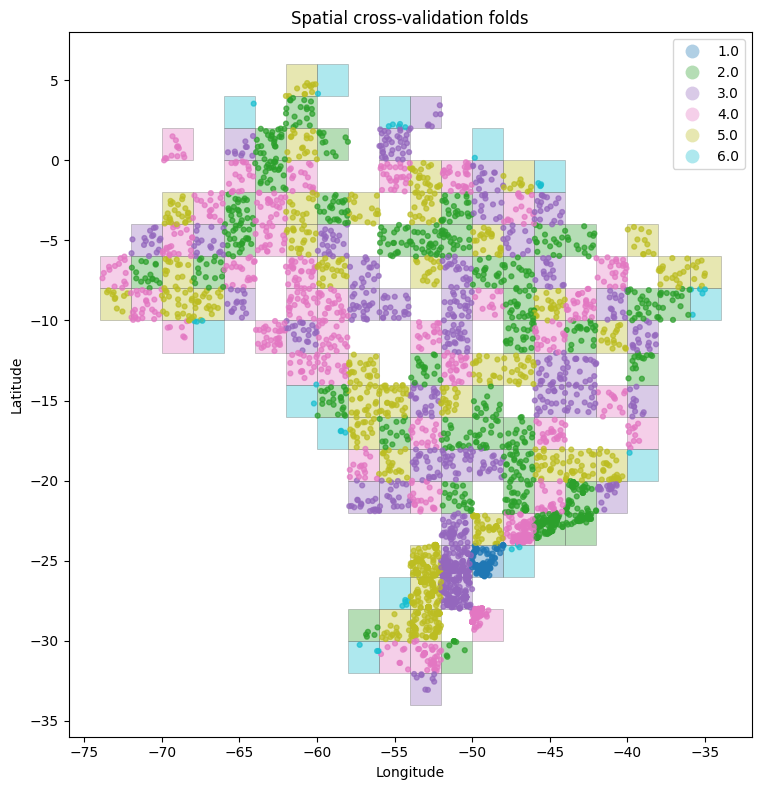

In [12]:
# Add partition/fold information to block polygons.
block_info = (
    samples_model[["block_id", "dataset", "fold"]]
    .drop_duplicates("block_id")
)

blocks_plot = blocks_gdf.merge(
    block_info,
    on="block_id",
    how="left"
)

# Plot spatial training folds.
fig, ax = plt.subplots(figsize=(10, 8))

training_blocks_plot = blocks_plot[
    blocks_plot["dataset"] == "Training"
].copy()

training_points_plot = samples_model[
    samples_model["dataset"] == "Training"
].copy()

training_blocks_plot.plot(
    ax=ax,
    column="fold",
    categorical=True,
    alpha=0.35,
    edgecolor="0.35",
    linewidth=0.6,
    legend=True,
)

training_points_plot.plot(
    ax=ax,
    column="fold",
    categorical=True,
    markersize=12,
    alpha=0.7,
)

ax.set_title("Spatial cross-validation folds")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


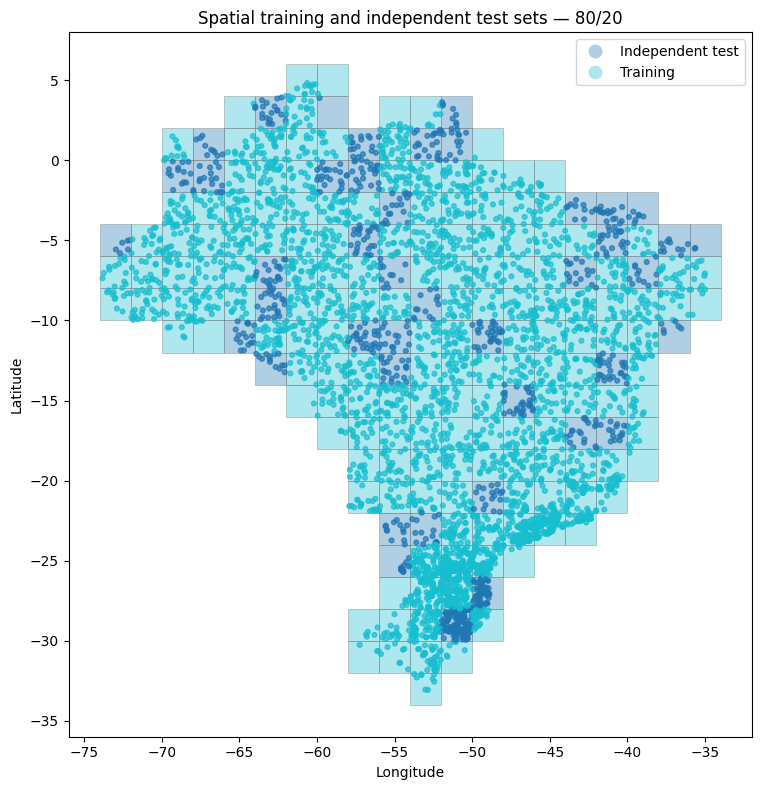

In [13]:
# Plot spatial training and independent test sets.
fig, ax = plt.subplots(figsize=(10, 8))

blocks_plot.plot(
    ax=ax,
    column="dataset",
    categorical=True,
    alpha=0.35,
    edgecolor="0.35",
    linewidth=0.6,
    legend=True,
)

samples_model.plot(
    ax=ax,
    column="dataset",
    categorical=True,
    markersize=12,
    alpha=0.7,
)

ax.set_title("Spatial training and independent test sets — 80/20")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


## 9. Build explicit scikit-learn spatial CV indices

The predictor matrix (`X`) and binary response (`y`) are divided according to the block-based spatial partition.


In [14]:
# Create predictor matrix and response vector.
X = samples_df.drop(columns="presence")
y = samples_df["presence"].astype(int)

train_mask = (
    samples_model["dataset"] == "Training"
).to_numpy()

test_mask = (
    samples_model["dataset"] == "Independent test"
).to_numpy()

X_train = X.loc[train_mask].reset_index(drop=True)
X_test = X.loc[test_mask].reset_index(drop=True)

y_train = y.loc[train_mask].reset_index(drop=True)
y_test = y.loc[test_mask].reset_index(drop=True)

train_spatial = samples_model.loc[train_mask].reset_index(drop=True)
test_spatial = samples_model.loc[test_mask].reset_index(drop=True)

print("Training samples:", len(X_train))
print("Independent test samples:", len(X_test))
print()
print("Training class distribution:")
print(y_train.value_counts().sort_index())
print()
print("Test class distribution:")
print(y_test.value_counts().sort_index())


Training samples: 5461
Independent test samples: 1366

Training class distribution:
presence
0    2730
1    2731
Name: count, dtype: int64

Test class distribution:
presence
0    683
1    683
Name: count, dtype: int64


In [17]:
# ============================================================
# BUILD SCIKIT-LEARN SPATIAL CV INDICES
# ============================================================

training_fold_id = train_spatial["fold"].astype(int).to_numpy()
spatial_cv = []

for fold in range(1, k_folds + 1):
    validation_idx = np.flatnonzero(training_fold_id == fold)
    train_idx = np.flatnonzero(training_fold_id != fold)

    # ROC AUC requires both classes in training and validation.
    if y_train.iloc[validation_idx].nunique() < 2:
        raise ValueError(f"Fold {fold} validation contains only one class.")
    if y_train.iloc[train_idx].nunique() < 2:
        raise ValueError(f"Fold {fold} training contains only one class.")

    spatial_cv.append((train_idx, validation_idx))

cv_index_summary = pd.DataFrame({
    "Fold": np.arange(1, k_folds + 1),
    "Training samples": [len(a) for a, _ in spatial_cv],
    "Validation samples": [len(b) for _, b in spatial_cv],
})

display(cv_index_summary)


ValueError: Fold 7 validation contains only one class.

In [16]:
# Check block leakage within every fold.
for fold, (train_idx, validation_idx) in enumerate(spatial_cv, start=1):
    train_blocks_fold = set(train_spatial.loc[train_idx, "block_id"])
    validation_blocks_fold = set(train_spatial.loc[validation_idx, "block_id"])

    if train_blocks_fold & validation_blocks_fold:
        raise RuntimeError(f"Spatial leakage detected in Fold {fold}.")

print(
    "Spatial leakage check passed: "
    "no block is shared between training and validation."
)


Spatial leakage check passed: no block is shared between training and validation.


## 10. Train and tune the Random Forest classifier

The Random Forest is tuned using the predefined spatial folds. **ROC AUC** is used to select the best hyperparameters because it evaluates probability ranking independently of a single classification threshold.


In [18]:
# Define the Random Forest classifier.
model_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=random_state,
    n_jobs=-1
)

# Small tuning grid for classroom use.
param_grid = {
    "max_features": ["sqrt", 0.5, 1.0],
    "min_samples_leaf": [1, 3, 5]
}

# Tune with predefined spatial folds.
grid_search = GridSearchCV(
    estimator=model_rf,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=spatial_cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Best model refitted on all training samples.
model_rf = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)

print()
print("Best mean spatial CV ROC AUC:")
print(round(grid_search.best_score_, 3))


Fitting 6 folds for each of 9 candidates, totalling 54 fits
Best parameters:
{'max_features': 'sqrt', 'min_samples_leaf': 3}

Best mean spatial CV ROC AUC:
0.968


## 11. Evaluate spatial cross-validation performance

Out-of-fold probabilities are generated using the spatial folds. A threshold of 0.50 converts probabilities to binary classes.


In [19]:
# Generate spatial out-of-fold probabilities.
prob_cv_all = cross_val_predict(
    model_rf,
    X_train,
    y_train,
    cv=spatial_cv,
    method="predict_proba",
    n_jobs=-1
)

# Locate the probability column for class 1.
class_1_idx = list(model_rf.classes_).index(1)
prob_cv = prob_cv_all[:, class_1_idx]

classification_threshold = 0.50
pred_cv = (prob_cv >= classification_threshold).astype("uint8")

metrics_cv = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC"
    ],
    "Value": [
        accuracy_score(y_train, pred_cv),
        balanced_accuracy_score(y_train, pred_cv),
        precision_score(y_train, pred_cv, zero_division=0),
        recall_score(y_train, pred_cv, zero_division=0),
        f1_score(y_train, pred_cv, zero_division=0),
        roc_auc_score(y_train, prob_cv),
    ]
})

display(metrics_cv.round(3))


,Metric,Value
0,Accuracy,0.950
1,Balanced accuracy,0.950
2,Precision,0.951
3,Recall,0.948
4,F1,0.950
5,ROC AUC,0.987


## 12. Examine variable importance

Permutation importance is calculated on the **independent spatial test set** using ROC AUC. This estimates how much each predictor contributes to discrimination in spatially unseen blocks.


In [20]:
# Calculate permutation importance on independent spatial test data.
perm_importance = permutation_importance(
    model_rf,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=random_state,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Variable": X_test.columns,
    "Importance": perm_importance.importances_mean
}).sort_values("Importance", ascending=False)

display(importance_df.head(20))


,Variable,Importance
6,bio11,0.002161
4,bio1,0.000736
20,bio7,0.000686
24,slope,0.000364
22,bio9,0.000350
8,bio13,0.000334
0,HAND,0.000332
11,bio16,0.000075
19,bio6,-0.000005
3,TPI_11x11,-0.000055


Permutation importance measures how much model performance decreases when the information from one predictor is destroyed.

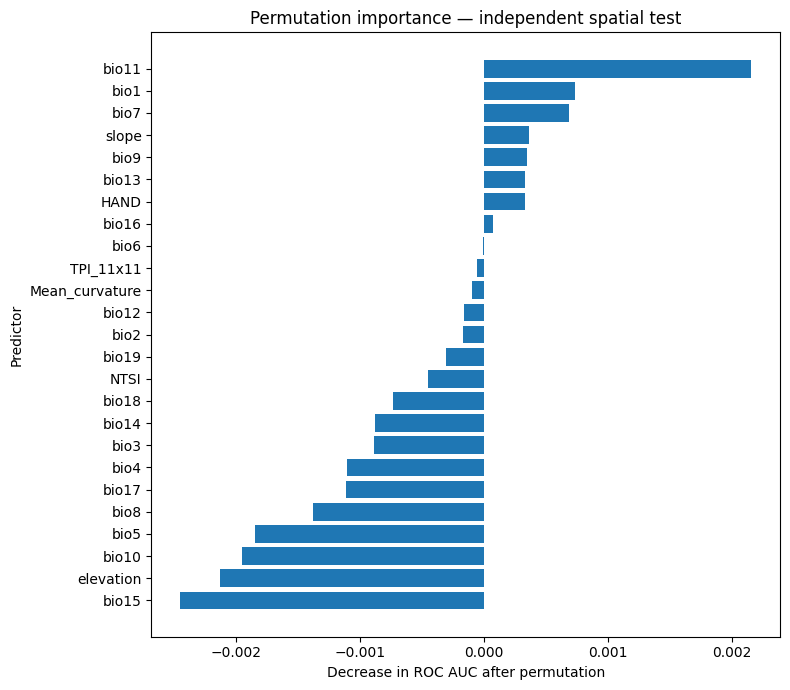

In [23]:
# Plot the most important predictors.
top_imp = importance_df.head(25).sort_values("Importance")

plt.figure(figsize=(8, 7))
plt.barh(top_imp["Variable"], top_imp["Importance"])
plt.xlabel("Decrease in ROC AUC after permutation")
plt.ylabel("Predictor")
plt.title("Permutation importance — independent spatial test")
plt.tight_layout()
plt.show()


## 13. Predict the independent spatial test data

The independent test contains complete blocks not used during model fitting or hyperparameter tuning.


In [24]:
# Predict probability of presence in unseen spatial blocks.
prob_test = model_rf.predict_proba(X_test)[:, class_1_idx]

# Convert probability to binary prediction.
pred_test = (
    prob_test >= classification_threshold
).astype("uint8")


## 14. Evaluate the independent spatial test

This is the main estimate of model performance in spatially unseen regions.


In [25]:
# Calculate independent spatial-test metrics.
metrics_test = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC"
    ],
    "Value": [
        accuracy_score(y_test, pred_test),
        balanced_accuracy_score(y_test, pred_test),
        precision_score(y_test, pred_test, zero_division=0),
        recall_score(y_test, pred_test, zero_division=0),
        f1_score(y_test, pred_test, zero_division=0),
        roc_auc_score(y_test, prob_test),
    ]
})

display(metrics_test.round(3))

print("Classification report:")
print(
    classification_report(
        y_test,
        pred_test,
        target_names=["Pseudo-absence", "Presence"],
        zero_division=0
    )
)


,Metric,Value
0,Accuracy,0.959
1,Balanced accuracy,0.959
2,Precision,0.969
3,Recall,0.949
4,F1,0.959
5,ROC AUC,0.986


Classification report:
                precision    recall  f1-score   support

Pseudo-absence       0.95      0.97      0.96       683
      Presence       0.97      0.95      0.96       683

      accuracy                           0.96      1366
     macro avg       0.96      0.96      0.96      1366
  weighted avg       0.96      0.96      0.96      1366



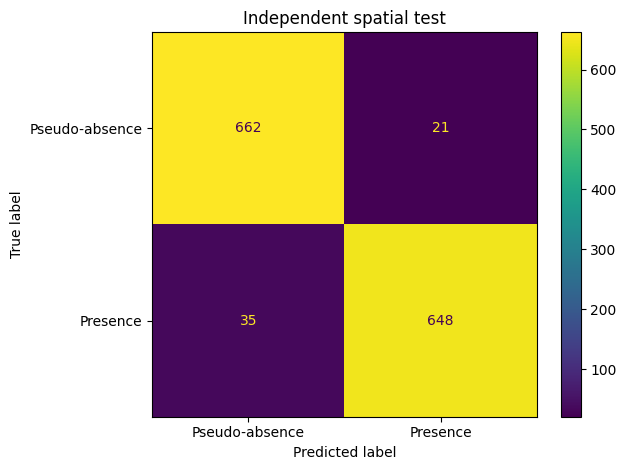

In [26]:
# Display the confusion matrix.
cm = confusion_matrix(y_test, pred_test, labels=[0, 1])

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Pseudo-absence", "Presence"]
).plot(values_format="d")

plt.title("Independent spatial test")
plt.tight_layout()
plt.show()


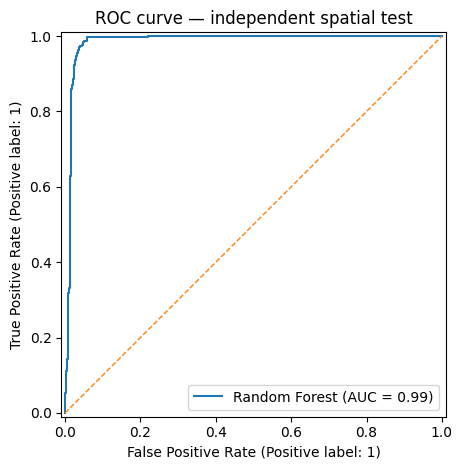

In [27]:
# Display the ROC curve for the independent spatial test.
RocCurveDisplay.from_predictions(
    y_test,
    prob_test,
    name="Random Forest"
)

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.title("ROC curve — independent spatial test")
plt.tight_layout()
plt.show()


## 15. Prepare raster predictors for mapping

Only predictors used by the fitted model are selected. All rasters must share the same CRS, extent, resolution, and grid alignment.


In [28]:
# Identify predictors used during training.
predictor_names = list(X_train.columns)

# Match predictor names to raster files.
raster_lookup = {f.stem: f for f in raster_files}

missing_vars = [
    name for name in predictor_names
    if name not in raster_lookup
]

if missing_vars:
    raise ValueError(
        "Missing raster predictors: " + ", ".join(missing_vars)
    )

predictor_rasters = [
    raster_lookup[name]
    for name in predictor_names
]

predictor_rasters


[PosixPath('/home/jovyan/grupos/pgrad-disciplinas/CAP-423-ciencia-de-dados-geoespaciais/dataset/input/HAND.tif'),
 PosixPath('/home/jovyan/grupos/pgrad-disciplinas/CAP-423-ciencia-de-dados-geoespaciais/dataset/input/Mean_curvature.tif'),
 PosixPath('/home/jovyan/grupos/pgrad-disciplinas/CAP-423-ciencia-de-dados-geoespaciais/dataset/input/NTSI.tif'),
 PosixPath('/home/jovyan/grupos/pgrad-disciplinas/CAP-423-ciencia-de-dados-geoespaciais/dataset/input/TPI_11x11.tif'),
 PosixPath('/home/jovyan/grupos/pgrad-disciplinas/CAP-423-ciencia-de-dados-geoespaciais/dataset/input/bio1.tif'),
 PosixPath('/home/jovyan/grupos/pgrad-disciplinas/CAP-423-ciencia-de-dados-geoespaciais/dataset/input/bio10.tif'),
 PosixPath('/home/jovyan/grupos/pgrad-disciplinas/CAP-423-ciencia-de-dados-geoespaciais/dataset/input/bio11.tif'),
 PosixPath('/home/jovyan/grupos/pgrad-disciplinas/CAP-423-ciencia-de-dados-geoespaciais/dataset/input/bio12.tif'),
 PosixPath('/home/jovyan/grupos/pgrad-disciplinas/CAP-423-ciencia-de-d

In [29]:
# Check that predictor rasters share the same grid.
reference_path = predictor_rasters[0]

with rasterio.open(reference_path) as ref:
    ref_shape = (ref.height, ref.width)
    ref_transform = ref.transform
    ref_crs = ref.crs

for path in predictor_rasters[1:]:
    with rasterio.open(path) as src:
        if (src.height, src.width) != ref_shape:
            raise ValueError(f"Raster shape mismatch: {path.name}")
        if not src.transform.almost_equals(ref_transform, precision=1e-6):
            raise ValueError(f"Raster transform mismatch: {path.name}")
        if src.crs != ref_crs:
            raise ValueError(f"Raster CRS mismatch: {path.name}")

print("All predictor rasters share the same grid.")


All predictor rasters share the same grid.


## 16. Predict the probability and binary occurrence maps

For each raster block, the model predicts the probability of class `1` (Araucaria presence). The binary map applies the same 0.50 threshold used during evaluation.


In [30]:
# Define output raster paths.
probability_output = OUTPUT_DIR / "Araucaria_RF_probability_spatialcv.tif"
binary_output = OUTPUT_DIR / "Araucaria_RF_binary_spatialcv.tif"

# Open predictor rasters once for efficient block processing.
sources = [rasterio.open(path) for path in predictor_rasters]

try:
    with rasterio.open(reference_path) as ref:
        probability_profile = ref.profile.copy()
        binary_profile = ref.profile.copy()

    probability_profile.update(
        count=1,
        dtype="float32",
        nodata=np.nan,
        compress="deflate",
        predictor=3,
        zlevel=9
    )

    # 255 is reserved as NoData because valid classes are 0 and 1.
    binary_profile.update(
        count=1,
        dtype="uint8",
        nodata=255,
        compress="deflate",
        zlevel=9
    )

    with rasterio.open(
        probability_output, "w", **probability_profile
    ) as dst_prob, rasterio.open(
        binary_output, "w", **binary_profile
    ) as dst_bin:

        for _, window in sources[0].block_windows(1):
            arrays = []
            valid_mask = None

            for src in sources:
                arr = src.read(1, window=window).astype("float32")

                current_valid = np.isfinite(arr)

                if src.nodata is not None:
                    current_valid &= arr != src.nodata

                valid_mask = (
                    current_valid
                    if valid_mask is None
                    else valid_mask & current_valid
                )

                arrays.append(arr)

            block_shape = arrays[0].shape

            prob_block = np.full(
                block_shape,
                np.nan,
                dtype="float32"
            )

            binary_block = np.full(
                block_shape,
                255,
                dtype="uint8"
            )

            if np.any(valid_mask):
                X_block = np.column_stack([
                    arr[valid_mask]
                    for arr in arrays
                ])

                X_block = pd.DataFrame(
                    X_block,
                    columns=predictor_names
                )

                probability = model_rf.predict_proba(
                    X_block
                )[:, class_1_idx]

                binary = (
                    probability >= classification_threshold
                ).astype("uint8")

                prob_block[valid_mask] = probability.astype("float32")
                binary_block[valid_mask] = binary

            dst_prob.write(prob_block, 1, window=window)
            dst_bin.write(binary_block, 1, window=window)

finally:
    for src in sources:
        src.close()

print("Probability map saved to:")
print(probability_output)
print()
print("Binary map saved to:")
print(binary_output)


Probability map saved to:
/home/jovyan/grupos/pgrad-disciplinas/CAP-423-ciencia-de-dados-geoespaciais/dataset/output/Araucaria_RF_probability_spatialcv.tif

Binary map saved to:
/home/jovyan/grupos/pgrad-disciplinas/CAP-423-ciencia-de-dados-geoespaciais/dataset/output/Araucaria_RF_binary_spatialcv.tif


## 17. Display the probability map

Values close to `1` indicate higher predicted probability of Araucaria presence.


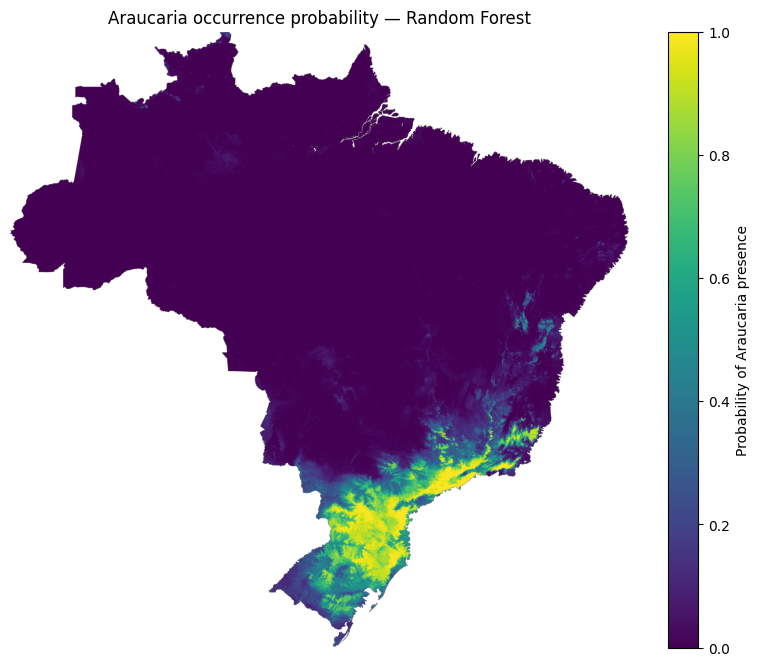

In [31]:
# Display probability of occurrence.
with rasterio.open(probability_output) as src:
    probability_map = src.read(1, masked=True)

plt.figure(figsize=(10, 8))
plt.imshow(probability_map, vmin=0, vmax=1)
plt.colorbar(label="Probability of Araucaria presence")
plt.title("Araucaria occurrence probability — Random Forest")
plt.axis("off")
plt.show()


## 18. Display the binary occurrence map

The binary map uses the fixed threshold `P(presence) ≥ 0.50` for presence.


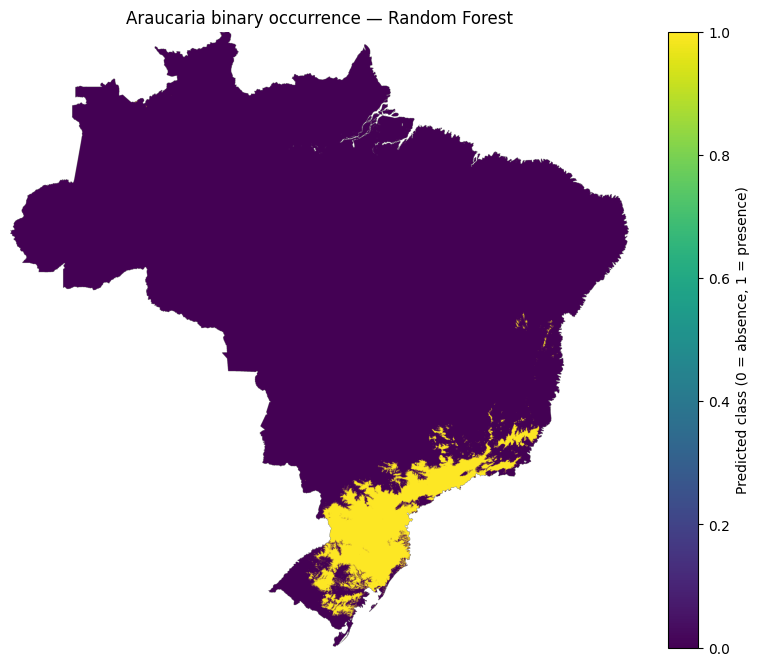

In [32]:
# Display binary occurrence prediction.
with rasterio.open(binary_output) as src:
    binary_map = src.read(1, masked=True)

plt.figure(figsize=(10, 8))
plt.imshow(binary_map, vmin=0, vmax=1)
plt.colorbar(label="Predicted class (0 = absence, 1 = presence)")
plt.title("Araucaria binary occurrence — Random Forest")
plt.axis("off")
plt.show()


## 19. Final spatial-validation checks

The final checks confirm that no spatial block is shared between training and independent testing or between training and validation within any cross-validation fold.


In [33]:
# Check train/test block separation.
assert not (
    set(train_spatial["block_id"])
    & set(test_spatial["block_id"])
)

# Check every spatial CV fold.
for train_idx, validation_idx in spatial_cv:
    assert not (
        set(train_spatial.loc[train_idx, "block_id"])
        & set(train_spatial.loc[validation_idx, "block_id"])
    )

print("FINAL CHECK PASSED")
print("- no block is shared between training and independent test")
print("- no block is shared within any spatial CV split")
print("- GridSearchCV used the predefined spatial folds")
print("- output 1: probability of presence (0–1)")
print("- output 2: binary occurrence (0/1)")


FINAL CHECK PASSED
- no block is shared between training and independent test
- no block is shared within any spatial CV split
- GridSearchCV used the predefined spatial folds
- output 1: probability of presence (0–1)
- output 2: binary occurrence (0/1)


## Summary

- The response is a binary presence/pseudo-absence variable.
- Spatial blocks are used for all validation partitions.
- Approximately **80%** of samples are used for training and **20%** for an independent spatial test.
- Hyperparameters are tuned with **10-fold spatial cross-validation** using ROC AUC.
- The independent test reports threshold-based metrics and ROC AUC.
- Two maps are produced: **probability of presence** and **binary occurrence**.
- The binary map uses a probability threshold of **0.50**; this threshold can be changed later if ecological or management objectives require a different sensitivity/specificity trade-off.
